# Propensity ≠ incremental conversion: a randomized targeting study

**Question.** With a fixed budget for a women's merchandise email, does ranking customers by their probability of buying without an email perform as well as ranking them by estimated incremental conversion? This is a reproducible analysis of Kevin Hillstrom's [MineThatData randomized email challenge](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html), not a claim about a live campaign or a personal deployment.

The original test randomized 64,000 customers across men's email, women's email, and no email. We preselect **women's email versus no email**; the men's arm is excluded because it is a different treatment. The outcome is conversion in the following two weeks. Treatment was randomized, so aggregate and held-out policy effects can be estimated without an observational selection-bias assumption. Individual treatment effects remain unobserved.

## Design before looking at the holdout

- Pre-treatment features only: recency, past spend, past men's/women's purchases, zip class, new-customer flag, and prior channel. We omit `history_segment` because it is derived from past spend. `visit`, `conversion`, and `spend` are post-treatment and never enter the models.
- Fixed seed, 50/50 train/test split. A **response-propensity** model learns $P(Y=1\mid X,T=0)$ on controls. A **T-learner** fits separate treated and control outcome models; its score is their difference. The same covariates and model class are used for both approaches.
- Predeclared contact budget: **30% of eligible customers**. Compare both rankings and a random 30% policy on the same untouched test set.
- Primary estimand: incremental conversions per 1,000 eligible customers versus no email, estimated from randomized assignment with known assignment probability and an augmented inverse-probability (AIPW) score. Bootstrap intervals describe test-set sampling uncertainty; they do not cover campaign drift or model-selection uncertainty.

The dataset does not contain profit margin, email cost, or follow-up campaigns. Any monetary value below is explicitly a scenario, not observed profit.

In [1]:
import hashlib
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

SEED = 2026
BUDGET = 0.30
SOURCE = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
SHA256 = "0e5893329d8b93cefecc571777672028290ab69865718020c78c7284f291aece"
cache = Path("notebook-runs/hillstrom.csv")
if not cache.exists():
    cache.parent.mkdir(parents=True, exist_ok=True)
    cache.write_bytes(urlopen(SOURCE, timeout=45).read())
assert hashlib.sha256(cache.read_bytes()).hexdigest() == SHA256, "Source changed: verify provenance before analysis"
df = pd.read_csv(cache)
assert df.shape == (64000, 12)
print(f"Source: {SOURCE}\nRows: {len(df):,} | SHA-256: {SHA256}")
display(df.groupby("segment", observed=True).agg(n=("conversion", "size"), conversion_rate=("conversion", "mean"), mean_spend=("spend", "mean")).round(4))

Source: http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv
Rows: 64,000 | SHA-256: 0e5893329d8b93cefecc571777672028290ab69865718020c78c7284f291aece


,n,conversion_rate,mean_spend
segment,,,
Mens E-Mail,21307,0.0125,1.4226
No E-Mail,21306,0.0057,0.6528
Womens E-Mail,21387,0.0088,1.0772


## Experiment audit

The assignment mechanism comes from the source documentation, not from a fitted propensity score. Within the two selected arms, the assignment probability for women's email is one half. We use that design probability in the estimator. Standardized mean differences (SMDs) check observed pre-treatment balance; small differences support the randomization description but cannot prove it.

In [2]:
d = df.loc[df.segment.isin(["Womens E-Mail", "No E-Mail"])].copy()
d["t"] = (d.segment == "Womens E-Mail").astype(int)
features = ["recency", "history", "mens", "womens", "zip_code", "newbie", "channel"]
X = d[features].copy()
X["log_history"] = np.log1p(X.pop("history"))
X = pd.get_dummies(X, columns=["zip_code", "channel"], dtype=float).astype(float)
y = d.conversion.to_numpy(dtype=float)
t = d.t.to_numpy(dtype=int)
train, test = train_test_split(np.arange(len(d)), test_size=.5, random_state=SEED, stratify=t)
Xtr, Xte = X.iloc[train], X.iloc[test]
ytr, yte, ttr, tte = y[train], y[test], t[train], t[test]
e = 0.5
rows=[]
for col in X.columns:
    a,b=X.loc[d.t.eq(1),col],X.loc[d.t.eq(0),col]
    scale=np.sqrt((a.var()+b.var())/2)
    rows.append((col, (a.mean()-b.mean())/scale if scale else 0))
balance=pd.DataFrame(rows,columns=["feature","SMD"])
print(f"Selected sample: {len(d):,}; train: {len(train):,}; untouched test: {len(test):,}; observed test P(T=1): {tte.mean():.4f}")
display(balance.assign(abs_SMD=lambda z:z.SMD.abs()).sort_values("abs_SMD",ascending=False).head(8).round(3))

Selected sample: 42,693; train: 21,346; untouched test: 21,347; observed test P(T=1): 0.5010


,feature,SMD,abs_SMD
1,mens,-0.009,0.009
9,channel_Phone,0.009,0.009
4,log_history,0.006,0.006
8,channel_Multichannel,-0.005,0.005
0,recency,0.005,0.005
10,channel_Web,-0.005,0.005
2,womens,0.005,0.005
5,zip_code_Rural,0.004,0.004


## Learn two rankings from training data only

The propensity baseline predicts purchases **without** treatment, the classic “who will buy?” question. The uplift score asks whether the treatment changes that probability. Both are estimates, not observed person-level causal effects. Hyperparameters and the 30% contact fraction are fixed here, before reading the test outcomes.

In [3]:
def learner():
    return HistGradientBoostingClassifier(max_iter=80, max_leaf_nodes=7, min_samples_leaf=100, l2_regularization=10.0, learning_rate=.05, random_state=SEED)
control = learner().fit(Xtr.loc[ttr==0],ytr[ttr==0])
treated = learner().fit(Xtr.loc[ttr==1],ytr[ttr==1])
mu0 = control.predict_proba(Xte)[:,1]
mu1 = treated.predict_proba(Xte)[:,1]
score_propensity = mu0
score_uplift = mu1-mu0
print(f"Holdout control-response AUC: {roc_auc_score(yte[tte==0],mu0[tte==0]):.3f}")
print(f"Estimated uplift score range: {score_uplift.min():.4f} to {score_uplift.max():.4f}")

Holdout control-response AUC: 0.593
Estimated uplift score range: -0.0070 to 0.0149


## Evaluate decisions, not classification scores

For a test customer, the AIPW pseudo-outcome is

$$\hat\tau_i=\hat\mu_1(X_i)-\hat\mu_0(X_i)+\frac{T_i}{e}(Y_i-\hat\mu_1(X_i))-\frac{1-T_i}{1-e}(Y_i-\hat\mu_0(X_i)).$$

Because treatment is randomized and $e$ is known by design, its average over a **fixed, training-derived** target set estimates the policy's incremental conversion probability relative to no email. Nuisance predictions were trained before the test set was inspected. We report paired bootstrap intervals for policy differences and avoid declaring superiority from point estimates alone.

In [4]:
rng=np.random.default_rng(SEED)
N=len(test)
k=round(BUDGET*N)
def top_mask(score):
    out=np.zeros(N,dtype=bool)
    out[np.argsort(-score,kind="stable")[:k]]=True
    return out
masks={"Propensity":top_mask(score_propensity),"Uplift":top_mask(score_uplift)}
random_mask=np.zeros(N,dtype=bool)
random_mask[rng.choice(N,k,replace=False)]=True
masks["Random"] = random_mask
psi=(mu1-mu0)+tte*(yte-mu1)/e-(1-tte)*(yte-mu0)/(1-e)
values={name:1000*np.mean(mask*psi) for name,mask in masks.items()}
B=1200
boot_idx=rng.integers(0,N,size=(B,N),dtype=np.int32)
boot={name:1000*np.mean((mask*psi)[boot_idx],axis=1) for name,mask in masks.items()}
results=pd.DataFrame([{"policy":name,"incremental_conversions_per_1000":val,"CI_low":np.quantile(boot[name],.025),"CI_high":np.quantile(boot[name],.975)} for name,val in values.items()])
display(results.round(3))
diff=boot["Uplift"]-boot["Propensity"]
print(f"Uplift minus propensity: {values['Uplift']-values['Propensity']:.3f} incremental conversions/1,000; paired 95% bootstrap interval [{np.quantile(diff,.025):.3f}, {np.quantile(diff,.975):.3f}]")
print(f"Overlap of targeted customers: {(masks['Uplift'] & masks['Propensity']).sum()/k:.1%}")

,policy,incremental_conversions_per_1000,CI_low,CI_high
0,Propensity,1.155,-0.370,2.747
1,Uplift,0.469,-0.686,1.591
2,Random,1.195,-0.010,2.547


Uplift minus propensity: -0.686 incremental conversions/1,000; paired 95% bootstrap interval [-2.627, 1.225]
Overlap of targeted customers: 1.0%


## Visual evidence

The left panel compares **equal-budget** held-out policy value. The right panel plots cumulative incremental conversions as contact coverage rises. The dashed line is the random-targeting expectation implied by the holdout average treatment effect. Curves are estimates and can be noisy at small coverage. AUUC/Qini-style areas are descriptive; the predeclared 30% comparison and its interval are the primary result.

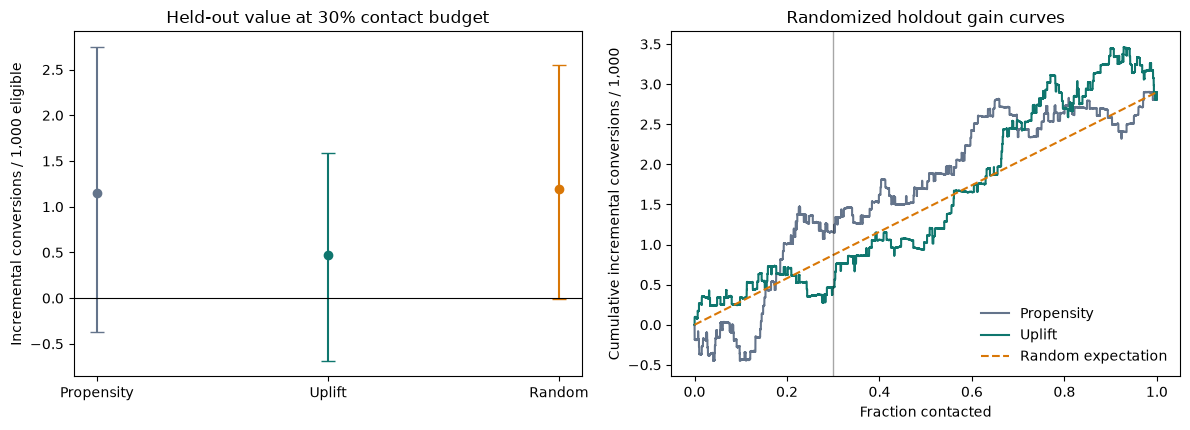

In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,4.4))
colors={"Propensity":"#64748b","Uplift":"#0f766e","Random":"#d97706"}
for name in ["Propensity","Uplift","Random"]:
    row=results.set_index("policy").loc[name]
    ax[0].errorbar(name,row.incremental_conversions_per_1000,yerr=[[row.incremental_conversions_per_1000-row.CI_low],[row.CI_high-row.incremental_conversions_per_1000]],fmt="o",capsize=5,color=colors[name])
ax[0].axhline(0,color="black",lw=.8)
ax[0].set_ylabel("Incremental conversions / 1,000 eligible")
ax[0].set_title("Held-out value at 30% contact budget")
coverage=np.arange(1,N+1)/N
for name,score in [("Propensity",score_propensity),("Uplift",score_uplift)]:
    order=np.argsort(-score,kind="stable")
    gains=1000*np.cumsum(psi[order])/N
    ax[1].plot(coverage,gains,label=name,color=colors[name])
ax[1].plot(coverage,coverage*1000*psi.mean(),"--",label="Random expectation",color=colors["Random"])
ax[1].axvline(BUDGET,color="black",alpha=.35,lw=1)
ax[1].set(xlabel="Fraction contacted",ylabel="Cumulative incremental conversions / 1,000",title="Randomized holdout gain curves")
ax[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## Cost and decision sensitivity

The dataset gives conversion and gross spend, **not contribution margin or contact cost**. The following is a decision scenario: assume each incremental conversion is worth **$50 contribution** and vary email cost. Net value per 1,000 eligible is estimated incremental conversions × $50 minus emails sent per 1,000 × assumed cost. Since each policy contacts the same 30%, cost cannot change their ordering. These are hypothetical dollars, not a measured P&L.

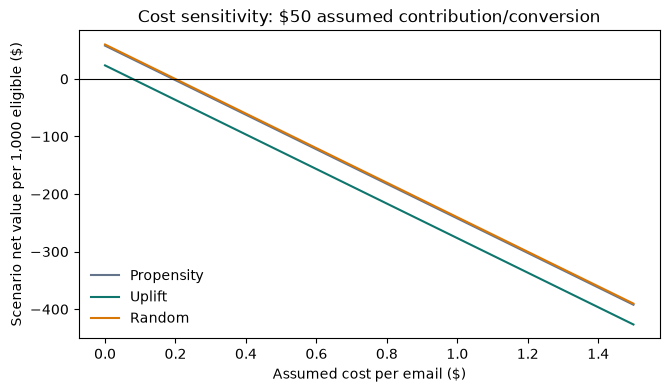

,policy,break_even_email_cost_USD_at_50_per_conversion
0,Propensity,0.192
1,Uplift,0.078
2,Random,0.199


In [6]:
value_per_conversion=50.0
costs=np.linspace(0,1.5,100)
fig,ax=plt.subplots(figsize=(7.5,4))
for name,val in values.items():
    ax.plot(costs,value_per_conversion*val-1000*BUDGET*costs,label=name,color=colors[name])
ax.axhline(0,color="black",lw=.8)
ax.set(xlabel="Assumed cost per email ($)",ylabel="Scenario net value per 1,000 eligible ($)",title="Cost sensitivity: $50 assumed contribution/conversion")
ax.legend(frameon=False)
plt.show()
display(pd.DataFrame({"policy":list(values),"break_even_email_cost_USD_at_50_per_conversion":[values[n]*value_per_conversion/(1000*BUDGET) for n in values]}).round(3))

## Interpretation and limits

This randomized example directly tests the infographic's useful core: response propensity and treatment effect are different objectives. A good response AUC cannot establish incremental value. The measured policy comparison above, including its uncertainty, is the evidence; the claim that any “60% AUC” uplift model **always** beats a “95% AUC” propensity model is not defensible.

CATE estimates here are model-dependent and unvalidated at the individual level. The holdout is a random half of **one historical campaign**, not a later campaign or a deployment. Intervals condition on the learned rankings and do not quantify temporal transport, repeated model selection, interference, email deliverability, or unknown margins. For a production decision, pre-register a fresh randomized holdout with the actual targeting policy and optimize observed contribution margin, including contact cost and operational constraints. The study is credible portfolio evidence of **evaluation discipline**, not proof of universal uplift superiority. In this fixed-seed holdout, the simple T-learner did **not** beat response propensity at the predeclared budget; the paired interval spans zero. That result is retained, not tuned away.